# 09 — GLM w stylu StatQuest: ekspresja genu, t-test, ANOVA i masa myszy

Ten notebook jest **dodatkiem do wykładu o regresji liniowej**. Pokazuje, że t-test i ANOVA można opowiedzieć tym samym językiem, co regresję liniową:

1. model zerowy: przewidujemy jedną średnią,
2. model dopasowany: przewidujemy średnią grupy albo liniową funkcję cech,
3. porównujemy `SSE_mean` i `SSE_fit`,
4. liczymy statystykę $F$ oraz p-value.

Nie używam tutaj dokładnych punktów z filmu. To jest **mały, syntetyczny odpowiednik dydaktyczny**, zrobiony tak, żeby na tablicy i w notebooku dało się łatwo policzyć najważniejsze rzeczy ręcznie.

## 0. Importy i funkcje pomocnicze

Ważna konwencja:

- `p` oznacza liczbę parametrów modelu, czyli liczbę kolumn w macierzy projektu `X`,
- jeśli `X` zawiera intercept, to intercept też liczy się jako parametr,
- w modelu średniej `p_mean = 1`, bo estymujemy tylko jedną liczbę: ogólną średnią.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import f as f_dist
from scipy.stats import ttest_ind, f_oneway

pd.set_option("display.precision", 4)


def fit_ols(X, y, column_names=None):
    """Dopasuj OLS przez najmniejsze kwadraty dla jawnej macierzy projektu X."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n, p = X.shape

    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    y_hat = X @ beta
    residuals = y - y_hat

    sse = np.sum(residuals ** 2)
    tss = np.sum((y - y.mean()) ** 2)
    r2 = 1 - sse / tss if tss > 0 else np.nan
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p) if n > p else np.nan

    if column_names is None:
        column_names = [f"beta_{j}" for j in range(p)]

    return {
        "beta": pd.Series(beta, index=column_names),
        "y_hat": y_hat,
        "residuals": residuals,
        "SSE": sse,
        "TSS": tss,
        "R2": r2,
        "adjusted_R2": adj_r2,
        "n": n,
        "p": p,
        "df_resid": n - p,
    }


def nested_f_test(simple, full):
    """Test F dla modeli zagnieżdżonych: czy model full znacząco zmniejsza SSE?"""
    sse_simple = simple["SSE"]
    sse_full = full["SSE"]
    p_simple = simple["p"]
    p_full = full["p"]
    n = full["n"]

    df_num = p_full - p_simple
    df_den = n - p_full

    F = ((sse_simple - sse_full) / df_num) / (sse_full / df_den)
    p_value = f_dist.sf(F, df_num, df_den)

    return pd.Series({
        "SSE_simple": sse_simple,
        "SSE_full": sse_full,
        "df_num": df_num,
        "df_den": df_den,
        "F": F,
        "p_value": p_value,
    })


def model_row(name, fit):
    return {
        "model": name,
        "p": fit["p"],
        "df_resid": fit["df_resid"],
        "SSE": fit["SSE"],
        "R2": fit["R2"],
        "adjusted_R2": fit["adjusted_R2"],
    }

## 1. Mini-przykład: ekspresja genu u myszy Control i Mutant

Pytanie badawcze:

> Czy średnia ekspresja genu różni się między myszami kontrolnymi i mutantami?

To brzmi jak klasyczny t-test. Ale można to zapisać jako model liniowy.

In [2]:
ttest_data = pd.DataFrame({
    "mouse_id": ["C1", "C2", "C3", "C4", "M1", "M2", "M3", "M4"],
    "genotype": ["Control"] * 4 + ["Mutant"] * 4,
    "gene_expression": [1.7, 2.1, 2.3, 2.7, 3.1, 3.4, 3.7, 4.2],
})

ttest_data

,mouse_id,genotype,gene_expression
0,C1,Control,1.7
1,C2,Control,2.1
2,C3,Control,2.3
3,C4,Control,2.7
4,M1,Mutant,3.1
5,M2,Mutant,3.4
6,M3,Mutant,3.7
7,M4,Mutant,4.2


In [3]:
summary = ttest_data.groupby("genotype")["gene_expression"].agg(["count", "mean", "std"])
summary.loc["Overall", :] = [len(ttest_data), ttest_data["gene_expression"].mean(), ttest_data["gene_expression"].std(ddof=1)]
summary

,count,mean,std
genotype,,,
Control,4.0,2.2,0.4163
Mutant,4.0,3.6,0.4690
Overall,8.0,2.9,0.8536


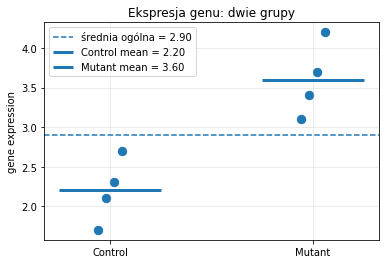

In [4]:
# Wykres: punkty + średnia ogólna + średnie grupowe.
position = {"Control": 0, "Mutant": 1}
x_pos = ttest_data["genotype"].map(position).to_numpy(dtype=float)
# mały deterministyczny jitter, żeby punkty nie nachodziły na siebie
jitter = np.array([-0.06, -0.02, 0.02, 0.06] * 2)

plt.figure(figsize=(6, 4))
plt.scatter(x_pos + jitter, ttest_data["gene_expression"], s=70)

overall_mean = ttest_data["gene_expression"].mean()
control_mean = ttest_data.loc[ttest_data["genotype"] == "Control", "gene_expression"].mean()
mutant_mean = ttest_data.loc[ttest_data["genotype"] == "Mutant", "gene_expression"].mean()

plt.axhline(overall_mean, linestyle="--", label=f"średnia ogólna = {overall_mean:.2f}")
plt.hlines(control_mean, -0.25, 0.25, linewidth=3, label=f"Control mean = {control_mean:.2f}")
plt.hlines(mutant_mean, 0.75, 1.25, linewidth=3, label=f"Mutant mean = {mutant_mean:.2f}")

plt.xticks([0, 1], ["Control", "Mutant"])
plt.ylabel("gene expression")
plt.title("Ekspresja genu: dwie grupy")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 2. Model zerowy: jedna średnia

Model zerowy mówi:

$$
\hat y_i = \bar y
$$

czyli każdej myszy przypisujemy tę samą predykcję: ogólną średnią ekspresji.

Macierz projektu ma jedną kolumnę jedynek:

$$
X_{mean}=\begin{bmatrix}
1\\1\\1\\1\\1\\1\\1\\1
\end{bmatrix}
$$

In [5]:
y = ttest_data["gene_expression"].to_numpy()
n = len(y)

X_mean = np.ones((n, 1))
fit_mean = fit_ols(X_mean, y, ["overall_mean"])

print("Parametr modelu zerowego:")
print(fit_mean["beta"])
print(f"\nSSE_mean = {fit_mean['SSE']:.4f}")

Parametr modelu zerowego:
overall_mean    2.9
dtype: float64

SSE_mean = 5.1000


## 3. Model grupowy jako design matrix

Teraz model dopasowany ma osobną średnią dla Control i osobną średnią dla Mutant:

$$
\hat y_i = I(\text{Control})\cdot \mu_{Control} + I(\text{Mutant})\cdot \mu_{Mutant}
$$

To jest dokładnie idea **design matrix**. Kolumna włącza albo wyłącza dany parametr.

In [6]:
X_group_df = pd.get_dummies(ttest_data["genotype"])[["Control", "Mutant"]].astype(float)
X_group_df

,Control,Mutant
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,0.0,1.0
5,0.0,1.0
6,0.0,1.0
7,0.0,1.0


In [7]:
fit_group = fit_ols(X_group_df.to_numpy(), y, X_group_df.columns.tolist())

print("Parametry modelu grupowego:")
print(fit_group["beta"])
print(f"\nSSE_fit = {fit_group['SSE']:.4f}")
print(f"R2 = {fit_group['R2']:.4f}")

Parametry modelu grupowego:
Control    2.2
Mutant     3.6
dtype: float64

SSE_fit = 1.1800
R2 = 0.7686


Interpretacja:

- model zerowy zna tylko jedną średnią,
- model grupowy zna dwie średnie,
- jeśli dwie średnie dużo zmniejszają SSE, to grupa wyjaśnia istotną część zmienności ekspresji.

In [8]:
comparison = pd.DataFrame([
    model_row("mean only", fit_mean),
    model_row("group means: Control + Mutant", fit_group),
])
comparison

,model,p,df_resid,SSE,R2,adjusted_R2
0,mean only,1,7,5.10,0.0000,0.0000
1,group means: Control + Mutant,2,6,1.18,0.7686,0.7301


## 4. Test F: ta sama logika co w regresji liniowej

Porównujemy model prosty i pełniejszy:

$$
F=\frac{(SSE_{simple}-SSE_{full})/(p_{full}-p_{simple})}{SSE_{full}/(n-p_{full})}
$$

Tutaj:

- `simple` = jedna średnia,
- `full` = dwie średnie grupowe,
- $p_{simple}=1$,
- $p_{full}=2$,
- $n=8$.

In [9]:
f_ttest = nested_f_test(fit_mean, fit_group)
f_ttest.to_frame("value")

,value
SSE_simple,5.1000
SSE_full,1.1800
df_num,1.0000
df_den,6.0000
F,19.9322
p_value,0.0043


Dla dwóch grup jednoczynnikowa ANOVA i klasyczny t-test z założeniem równej wariancji są równoważne w tym sensie, że:

$$
F = t^2
$$

To jest świetne krótkie ćwiczenie na tablicę.

In [10]:
control_y = ttest_data.loc[ttest_data["genotype"] == "Control", "gene_expression"]
mutant_y = ttest_data.loc[ttest_data["genotype"] == "Mutant", "gene_expression"]

t_stat, p_ttest = ttest_ind(control_y, mutant_y, equal_var=True)

pd.DataFrame({
    "method": ["linear model F", "two-sample t-test"],
    "statistic": [f_ttest["F"], t_stat],
    "statistic_squared_if_t": [np.nan, t_stat**2],
    "p_value": [f_ttest["p_value"], p_ttest],
})

,method,statistic,statistic_squared_if_t,p_value
0,linear model F,19.9322,NaN,0.0043
1,two-sample t-test,-4.4645,19.9322,0.0043


## 5. Ta sama predykcja, inna macierz: standardowy zapis z interceptem

W praktyce częściej spotkasz zapis:

$$
\hat y = \beta_0 + \beta_1 I(\text{Mutant})
$$

Wtedy:

- $\beta_0$ = średnia Control,
- $\beta_1$ = różnica między Mutant i Control.

Predykcje są takie same jak w modelu z dwiema kolumnami `Control` i `Mutant`. Zmienia się tylko interpretacja współczynników.

In [11]:
X_standard = pd.DataFrame({
    "intercept": 1.0,
    "is_mutant": (ttest_data["genotype"] == "Mutant").astype(float),
})

fit_standard = fit_ols(X_standard.to_numpy(), y, X_standard.columns.tolist())

print("Parametry standardowego zapisu:")
print(fit_standard["beta"])
print(f"\nCzy predykcje są identyczne? {np.allclose(fit_group['y_hat'], fit_standard['y_hat'])}")

Parametry standardowego zapisu:
intercept    2.2
is_mutant    1.4
dtype: float64

Czy predykcje są identyczne? True


## 6. ANOVA jako model średnich dla wielu grup

Teraz rozszerzamy przykład do pięciu kategorii:

- `Control`,
- `Mutant`,
- `Control_funky_diet`,
- `Mutant_funky_diet`,
- `Heterozygous`.

ANOVA pyta:

> Czy wszystkie średnie grupowe są takie same?

W języku modeli liniowych: czy model z pięcioma średnimi jest istotnie lepszy niż model z jedną średnią ogólną?

In [12]:
anova_data = pd.DataFrame({
    "group": (
        ["Control"] * 4
        + ["Mutant"] * 4
        + ["Control_funky_diet"] * 4
        + ["Mutant_funky_diet"] * 4
        + ["Heterozygous"] * 4
    ),
    "gene_expression": [
        1.7, 2.1, 2.3, 2.7,
        3.1, 3.4, 3.7, 4.2,
        2.3, 2.8, 3.0, 3.4,
        3.5, 3.8, 4.1, 4.5,
        2.4, 2.7, 3.0, 3.2,
    ],
})

anova_data.groupby("group")["gene_expression"].agg(["count", "mean", "std"])

,count,mean,std
group,,,
Control,4,2.200,0.4163
Control_funky_diet,4,2.875,0.4573
Heterozygous,4,2.825,0.3500
Mutant,4,3.600,0.4690
Mutant_funky_diet,4,3.975,0.4272


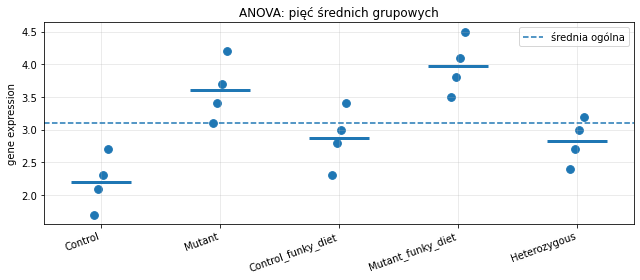

In [13]:
# Wykres grupowy
categories = ["Control", "Mutant", "Control_funky_diet", "Mutant_funky_diet", "Heterozygous"]
pos = {cat: i for i, cat in enumerate(categories)}
x = anova_data["group"].map(pos).to_numpy(dtype=float)
jitter = np.tile(np.array([-0.06, -0.02, 0.02, 0.06]), len(categories))

plt.figure(figsize=(9, 4))
plt.scatter(x + jitter, anova_data["gene_expression"], s=60)
plt.axhline(anova_data["gene_expression"].mean(), linestyle="--", label="średnia ogólna")

for cat in categories:
    m = anova_data.loc[anova_data["group"] == cat, "gene_expression"].mean()
    plt.hlines(m, pos[cat] - 0.25, pos[cat] + 0.25, linewidth=3)

plt.xticks(range(len(categories)), categories, rotation=20, ha="right")
plt.ylabel("gene expression")
plt.title("ANOVA: pięć średnich grupowych")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
y_anova = anova_data["gene_expression"].to_numpy()
X_anova_mean = np.ones((len(y_anova), 1))
fit_anova_mean = fit_ols(X_anova_mean, y_anova, ["overall_mean"])

X_anova_groups_df = pd.get_dummies(anova_data["group"])[categories].astype(float)
fit_anova_groups = fit_ols(X_anova_groups_df.to_numpy(), y_anova, categories)

anova_design_preview = pd.concat([anova_data, X_anova_groups_df], axis=1)
anova_design_preview.head(12)

,group,gene_expression,Control,Mutant,Control_funky_diet,Mutant_funky_diet,Heterozygous
0,Control,1.7,1.0,0.0,0.0,0.0,0.0
1,Control,2.1,1.0,0.0,0.0,0.0,0.0
2,Control,2.3,1.0,0.0,0.0,0.0,0.0
3,Control,2.7,1.0,0.0,0.0,0.0,0.0
4,Mutant,3.1,0.0,1.0,0.0,0.0,0.0
5,Mutant,3.4,0.0,1.0,0.0,0.0,0.0
6,Mutant,3.7,0.0,1.0,0.0,0.0,0.0
7,Mutant,4.2,0.0,1.0,0.0,0.0,0.0
8,Control_funky_diet,2.3,0.0,0.0,1.0,0.0,0.0
9,Control_funky_diet,2.8,0.0,0.0,1.0,0.0,0.0


In [15]:
pd.DataFrame([
    model_row("mean only", fit_anova_mean),
    model_row("five group means", fit_anova_groups),
])

,model,p,df_resid,SSE,R2,adjusted_R2
0,mean only,1,19,10.5295,0.0000,0.0000
1,five group means,5,15,2.7225,0.7414,0.6725


In [16]:
f_anova = nested_f_test(fit_anova_mean, fit_anova_groups)
f_anova.to_frame("value")

,value
SSE_simple,10.5295
SSE_full,2.7225
df_num,4.0000
df_den,15.0000
F,10.7534
p_value,0.0003


In [17]:
# Porównanie z gotową funkcją scipy.stats.f_oneway.
grouped_values = [anova_data.loc[anova_data["group"] == cat, "gene_expression"] for cat in categories]
F_scipy, p_scipy = f_oneway(*grouped_values)

pd.DataFrame({
    "method": ["manual linear model", "scipy.stats.f_oneway"],
    "F": [f_anova["F"], F_scipy],
    "p_value": [f_anova["p_value"], p_scipy],
})

,method,F,p_value
0,manual linear model,10.7534,0.0003
1,scipy.stats.f_oneway,10.7534,0.0003


## 7. Rozszerzenie praktyczne: ekspresja genu, masa myszy i genotyp

Teraz robimy wariant bardziej „ML-owy” i badawczy:

> Czy genotyp wpływa na ekspresję genu, jeśli uwzględnimy masę myszy?

To jest ważne, bo proste porównanie średnich może być mylące, jeśli grupy różnią się masą. Model liniowy pozwala włożyć do jednego równania zmienną ciągłą i kategoryczną:

$$
\widehat{expression} = \beta_0 + \beta_1\cdot weight + \beta_2\cdot I(\text{Mutant})
$$

In [18]:
weight_data = pd.DataFrame({
    "mouse_id": [f"C{i}" for i in range(1, 9)] + [f"M{i}" for i in range(1, 9)],
    "genotype": ["Control"] * 8 + ["Mutant"] * 8,
    "mouse_weight": [
        18.5, 19.2, 20.1, 21.0, 22.4, 23.2, 24.1, 25.0,
        18.8, 19.6, 20.5, 21.2, 22.0, 23.0, 24.5, 25.2,
    ],
    "gene_expression": [
        1.58, 1.82, 2.43, 2.33, 2.00, 2.54, 2.54, 2.89,
        2.24, 2.84, 2.99, 3.45, 3.27, 3.49, 3.24, 4.30,
    ],
})

weight_data

,mouse_id,genotype,mouse_weight,gene_expression
0,C1,Control,18.5,1.58
1,C2,Control,19.2,1.82
2,C3,Control,20.1,2.43
3,C4,Control,21.0,2.33
4,C5,Control,22.4,2.00
5,C6,Control,23.2,2.54
6,C7,Control,24.1,2.54
7,C8,Control,25.0,2.89
8,M1,Mutant,18.8,2.24
9,M2,Mutant,19.6,2.84


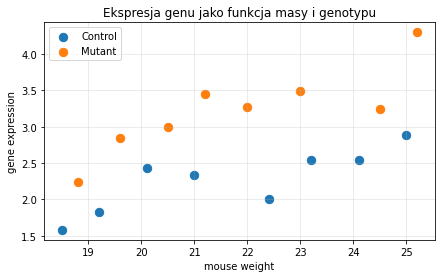

In [19]:
plt.figure(figsize=(7, 4))
for genotype in ["Control", "Mutant"]:
    d = weight_data[weight_data["genotype"] == genotype]
    plt.scatter(d["mouse_weight"], d["gene_expression"], s=70, label=genotype)

plt.xlabel("mouse weight")
plt.ylabel("gene expression")
plt.title("Ekspresja genu jako funkcja masy i genotypu")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Porównamy pięć modeli:

1. `mean only`: jedna średnia,
2. `weight only`: ekspresja zależy tylko od masy,
3. `genotype only`: ekspresja zależy tylko od grupy,
4. `weight + genotype`: model addytywny,
5. `weight + genotype + interaction`: osobne nachylenie dla Control i Mutant.

In [20]:
y_w = weight_data["gene_expression"].to_numpy()
w = weight_data["mouse_weight"].to_numpy()
is_mutant = (weight_data["genotype"] == "Mutant").astype(float).to_numpy()

X0 = np.ones((len(y_w), 1))
X_weight = np.column_stack([np.ones(len(y_w)), w])
X_genotype = np.column_stack([np.ones(len(y_w)), is_mutant])
X_full = np.column_stack([np.ones(len(y_w)), w, is_mutant])
X_interaction = np.column_stack([np.ones(len(y_w)), w, is_mutant, w * is_mutant])

fits = {
    "mean only": fit_ols(X0, y_w, ["intercept"]),
    "weight only": fit_ols(X_weight, y_w, ["intercept", "mouse_weight"]),
    "genotype only": fit_ols(X_genotype, y_w, ["intercept", "is_mutant"]),
    "weight + genotype": fit_ols(X_full, y_w, ["intercept", "mouse_weight", "is_mutant"]),
    "weight + genotype + interaction": fit_ols(X_interaction, y_w, ["intercept", "mouse_weight", "is_mutant", "weight:is_mutant"]),
}

pd.DataFrame([model_row(name, fit) for name, fit in fits.items()])

,model,p,df_resid,SSE,R2,adjusted_R2
0,mean only,1,15,7.4591,0.0000,0.0000
1,weight only,2,14,4.6400,0.3779,0.3335
2,genotype only,2,14,3.7631,0.4955,0.4595
3,weight + genotype,3,13,1.1771,0.8422,0.8179
4,weight + genotype + interaction,4,12,1.0901,0.8539,0.8173


In [21]:
for name in ["weight only", "genotype only", "weight + genotype", "weight + genotype + interaction"]:
    print("\n", name)
    print(fits[name]["beta"])


 weight only
intercept      -1.4670
mouse_weight    0.1936
dtype: float64

 genotype only
intercept    2.2662
is_mutant    0.9612
dtype: float64

 weight + genotype
intercept      -1.7574
mouse_weight    0.1855
is_mutant       0.9311
dtype: float64

 weight + genotype + interaction
intercept          -1.0455
mouse_weight        0.1527
is_mutant          -0.5521
weight:is_mutant    0.0681
dtype: float64


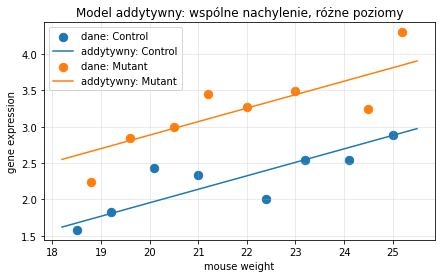

In [22]:
# Linie predykcji dla modelu addytywnego i interakcyjnego.
w_grid = np.linspace(weight_data["mouse_weight"].min() - 0.3, weight_data["mouse_weight"].max() + 0.3, 100)

plt.figure(figsize=(7, 4))
for genotype, m in [("Control", 0.0), ("Mutant", 1.0)]:
    d = weight_data[weight_data["genotype"] == genotype]
    plt.scatter(d["mouse_weight"], d["gene_expression"], s=70, label=f"dane: {genotype}")

    X_line = np.column_stack([np.ones(len(w_grid)), w_grid, np.full(len(w_grid), m)])
    y_line = X_line @ fits["weight + genotype"]["beta"].to_numpy()
    plt.plot(w_grid, y_line, label=f"addytywny: {genotype}")

plt.xlabel("mouse weight")
plt.ylabel("gene expression")
plt.title("Model addytywny: wspólne nachylenie, różne poziomy")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 8. Testy F dla modeli zagnieżdżonych

Teraz nie pytamy tylko „czy model jest lepszy od średniej?”. Możemy pytać dokładniej:

1. Czy genotyp dodaje informację po uwzględnieniu masy?
2. Czy masa dodaje informację po uwzględnieniu genotypu?
3. Czy potrzebujemy interakcji, czyli osobnego nachylenia dla grup?

In [23]:
nested_tests = pd.DataFrame({
    "full model vs weight only: czy genotyp coś dodaje?": nested_f_test(fits["weight only"], fits["weight + genotype"]),
    "full model vs genotype only: czy masa coś dodaje?": nested_f_test(fits["genotype only"], fits["weight + genotype"]),
    "interaction vs additive: czy nachylenia różnią się między grupami?": nested_f_test(fits["weight + genotype"], fits["weight + genotype + interaction"]),
}).T

nested_tests

,SSE_simple,SSE_full,df_num,df_den,F,p_value
full model vs weight only: czy genotyp coś dodaje?,4.6400,1.1771,1.0,13.0,38.2447,3.3012e-05
full model vs genotype only: czy masa coś dodaje?,3.7631,1.1771,1.0,13.0,28.5602,1.3332e-04
interaction vs additive: czy nachylenia różnią się między grupami?,1.1771,1.0901,1.0,12.0,0.9583,3.4694e-01


Interpretacja dydaktyczna:

- Model `weight + genotype` zwykle jest dużo bardziej informacyjny niż modele jednoczynnikowe.
- Współczynnik `is_mutant` oznacza przesunięcie poziomu ekspresji między grupami przy tej samej masie.
- Interakcja `weight:is_mutant` oznacza, że zależność ekspresji od masy ma inne nachylenie w grupie Mutant niż w Control.
- Jeśli test interakcji nie jest przekonujący, prostszy model addytywny jest lepszy do tłumaczenia.

## 9. Proste ćwiczenia na zajęcia

### Ćwiczenie 1 — średnie i SSE

Dla danych z dwóch grup policz ręcznie:

1. średnią ogólną,
2. średnią Control,
3. średnią Mutant,
4. `SSE_mean`,
5. `SSE_fit`.

Dane:

| grupa | ekspresja |
|---|---:|
| Control | 1.7 |
| Control | 2.1 |
| Control | 2.3 |
| Control | 2.7 |
| Mutant | 3.1 |
| Mutant | 3.4 |
| Mutant | 3.7 |
| Mutant | 4.2 |

### Ćwiczenie 2 — design matrix

Zapisz macierz projektu dla modelu:

$$
\hat y_i = I(\text{Control})\mu_C + I(\text{Mutant})\mu_M
$$

Pierwsze cztery wiersze powinny mieć postać `[1, 0]`, a kolejne cztery `[0, 1]`.

### Ćwiczenie 3 — test F

Użyj wartości:

- `SSE_mean = 5.10`,
- `SSE_fit = 1.18`,
- `n = 8`,
- `p_mean = 1`,
- `p_fit = 2`.

Policz:

$$
F=\frac{(SSE_{mean}-SSE_{fit})/(p_{fit}-p_{mean})}{SSE_{fit}/(n-p_{fit})}
$$

### Ćwiczenie 4 — interpretacja współczynników

W modelu:

$$
\widehat{expression}=\beta_0+\beta_1\cdot weight+\beta_2\cdot I(\text{Mutant})
$$

wytłumacz słownie, co znaczą $\beta_1$ i $\beta_2$.

### Ćwiczenie 5 — pułapka biologiczna / ML

Załóżmy, że myszy mutanty są przeciętnie cięższe. Dlaczego samo porównanie średnich ekspresji może być mylące? Kiedy warto dodać `mouse_weight` do modelu?

## 10. Krótki skrypt tablicowy

Możesz to poprowadzić na tablicy w 10 minut:

1. Narysuj dwie grupy punktów: Control i Mutant.
2. Narysuj jedną średnią ogólną i nazwij ją „model zerowy”.
3. Narysuj dwie średnie grupowe i nazwij je „model dopasowany”.
4. Powiedz: „Regresja minimalizuje sumę kwadratów reszt. Tutaj średnie grupowe też minimalizują sumę kwadratów reszt”.
5. Wprowadź design matrix jako przełączniki `0/1`.
6. Policz `SSE_mean`, `SSE_fit`, $F$.
7. Powiedz: „t-test, ANOVA i regresja liniowa są różnymi twarzami tego samego języka modeli liniowych”.